## IMPORTING DATA AND LIBRARIES 

In [ ]:
!pip install xgboost

In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import GroupKFold
import xgboost as xgb
from sklearn.preprocessing import StandardScaler

In [21]:
pdt= pd.read_csv('telemonitoring_parkinsons_updrs.data.csv')

In [22]:
pdt.head()

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


In [23]:
pdt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5875 entries, 0 to 5874
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   subject#       5875 non-null   int64  
 1   age            5875 non-null   int64  
 2   sex            5875 non-null   int64  
 3   test_time      5875 non-null   float64
 4   motor_UPDRS    5875 non-null   float64
 5   total_UPDRS    5875 non-null   float64
 6   Jitter(%)      5875 non-null   float64
 7   Jitter(Abs)    5875 non-null   float64
 8   Jitter:RAP     5875 non-null   float64
 9   Jitter:PPQ5    5875 non-null   float64
 10  Jitter:DDP     5875 non-null   float64
 11  Shimmer        5875 non-null   float64
 12  Shimmer(dB)    5875 non-null   float64
 13  Shimmer:APQ3   5875 non-null   float64
 14  Shimmer:APQ5   5875 non-null   float64
 15  Shimmer:APQ11  5875 non-null   float64
 16  Shimmer:DDA    5875 non-null   float64
 17  NHR            5875 non-null   float64
 18  HNR     

In [24]:
pdt.isnull().sum()

subject#         0
age              0
sex              0
test_time        0
motor_UPDRS      0
total_UPDRS      0
Jitter(%)        0
Jitter(Abs)      0
Jitter:RAP       0
Jitter:PPQ5      0
Jitter:DDP       0
Shimmer          0
Shimmer(dB)      0
Shimmer:APQ3     0
Shimmer:APQ5     0
Shimmer:APQ11    0
Shimmer:DDA      0
NHR              0
HNR              0
RPDE             0
DFA              0
PPE              0
dtype: int64

In [25]:
# Ensured that data is sorted chronologically by patient and timestamp
pdt = pdt.sort_values(by=['subject#', 'test_time']).reset_index(drop=True)

In [26]:
pdt.head(300)

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.160060
1,1,72,0,5.6431,28.199,34.398,0.00348,0.000015,0.00124,0.00133,...,0.113,0.00411,0.00463,0.00949,0.01234,0.009238,27.927,0.37340,0.52499,0.170660
2,1,72,0,5.6438,28.199,34.398,0.00413,0.000021,0.00173,0.00165,...,0.125,0.00555,0.00651,0.01103,0.01665,0.030790,26.641,0.50911,0.53637,0.251830
3,1,72,0,5.6451,28.199,34.398,0.00217,0.000011,0.00086,0.00099,...,0.072,0.00271,0.00354,0.00781,0.00812,0.004547,30.749,0.41216,0.54572,0.094704
4,1,72,0,5.6458,28.199,34.399,0.00294,0.000015,0.00121,0.00125,...,0.098,0.00459,0.00495,0.00888,0.01377,0.014919,27.530,0.40986,0.53572,0.166350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,3,57,0,7.2882,23.437,25.729,0.00695,0.000039,0.00389,0.00361,...,0.213,0.01349,0.01431,0.01684,0.04048,0.018448,19.743,0.46319,0.56117,0.236110
296,3,57,0,7.2882,23.437,25.729,0.00527,0.000029,0.00292,0.00324,...,0.230,0.01465,0.01629,0.01951,0.04396,0.012843,21.320,0.40321,0.56096,0.225950
297,3,57,0,7.2896,23.437,25.729,0.00392,0.000023,0.00187,0.00214,...,0.195,0.00904,0.01050,0.01443,0.02711,0.024464,27.149,0.37463,0.54994,0.170390
298,3,57,0,7.2903,23.437,25.729,0.00433,0.000023,0.00213,0.00264,...,0.114,0.00558,0.00664,0.00827,0.01674,0.017805,22.979,0.39077,0.55398,0.236490


## EXPLORATORY DATA ANALYSIS 

In [9]:
# Counts how many times each subject# appears, sorted by subject number
row_counts = pdt['subject#'].value_counts().sort_index()
print(row_counts)

subject#
1     149
2     145
3     144
4     137
5     156
6     156
7     161
8     150
9     152
10    148
11    138
12    107
13    112
14    136
15    143
16    138
17    144
18    126
19    129
20    134
21    123
22    112
23    138
24    156
25    144
26    130
27    129
28    134
29    168
30    126
31    130
32    101
33    135
34    161
35    165
36    129
37    140
38    149
39    143
40    142
41    165
42    150
Name: count, dtype: int64


In [10]:
pdt.shape

(5875, 22)

In [11]:
# Look at the test times and UPDRS scores for the first subject
print(pdt[pdt['subject#'] == 1][['subject#', 'test_time', 'motor_UPDRS','total_UPDRS']].head(15))

    subject#  test_time  motor_UPDRS  total_UPDRS
0          1     5.6431       28.199       34.398
1          1     5.6431       28.199       34.398
2          1     5.6438       28.199       34.398
3          1     5.6451       28.199       34.398
4          1     5.6458       28.199       34.399
5          1     5.6458       28.199       34.399
6          1    12.6660       28.447       34.894
7          1    12.6670       28.447       34.894
8          1    12.6670       28.447       34.894
9          1    12.6690       28.447       34.894
10         1    12.6690       28.447       34.894
11         1    12.6690       28.447       34.894
12         1    19.6810       28.695       35.389
13         1    19.6820       28.695       35.389
14         1    19.6820       28.695       35.389


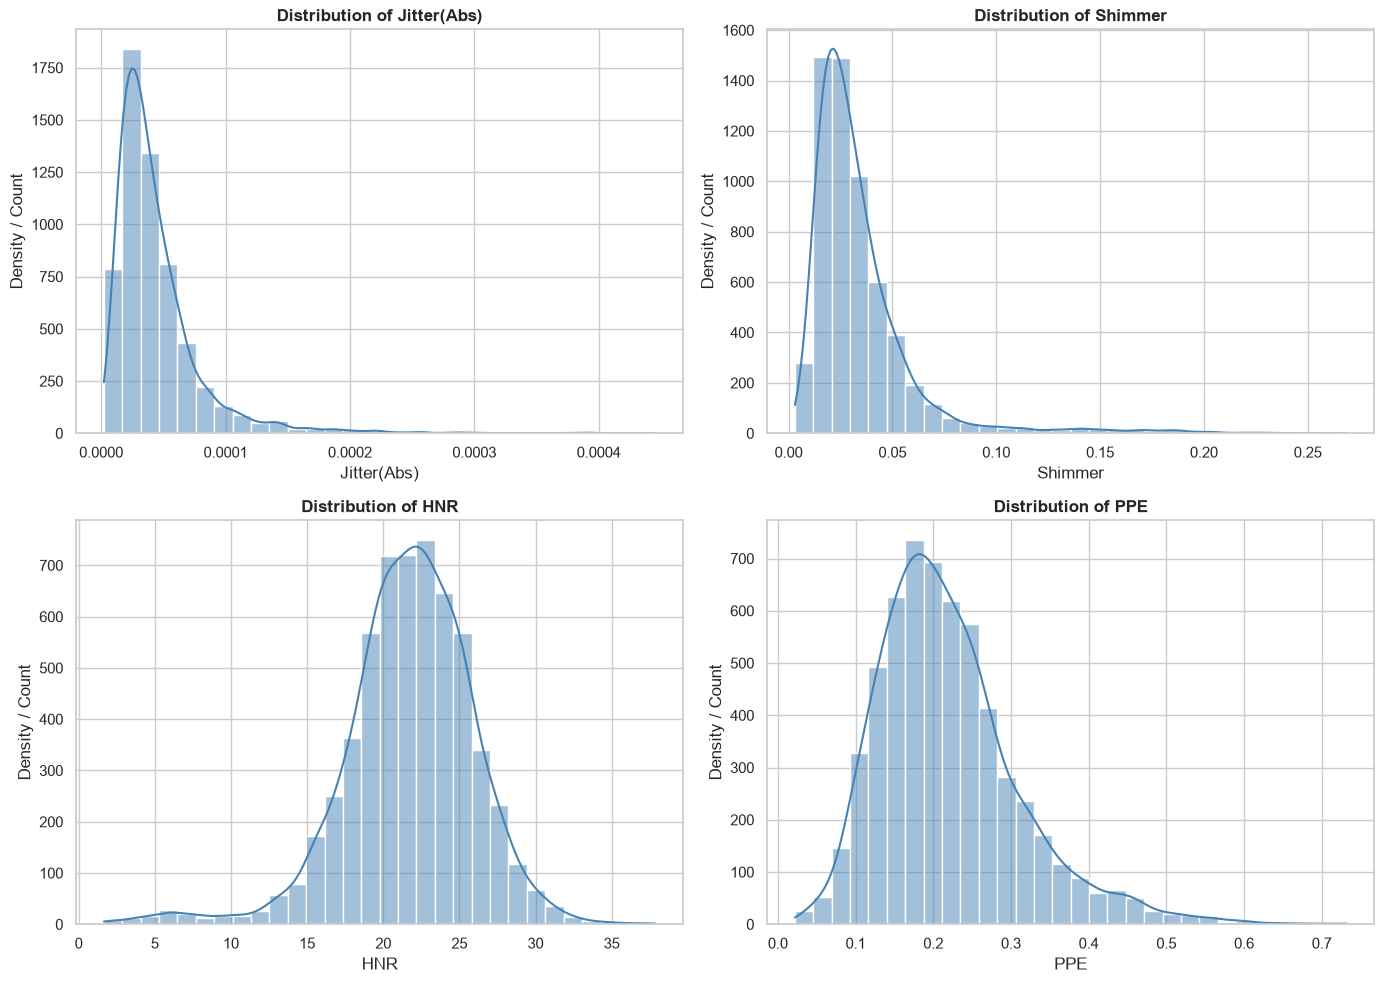

In [12]:
# Set visual style
sns.set_theme(style="whitegrid")


# Comparing classical skewed features vs. non-classical features
features_to_plot = ['Jitter(Abs)', 'Shimmer', 'HNR', 'PPE']

# Create a multi-panel figure for distributions
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    sns.histplot(
        pdt[feature], 
        kde=True, 
        ax=axes[i], 
        color='steelblue', 
        bins=30
    )
    axes[i].set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Density / Count')

plt.tight_layout()
plt.show()

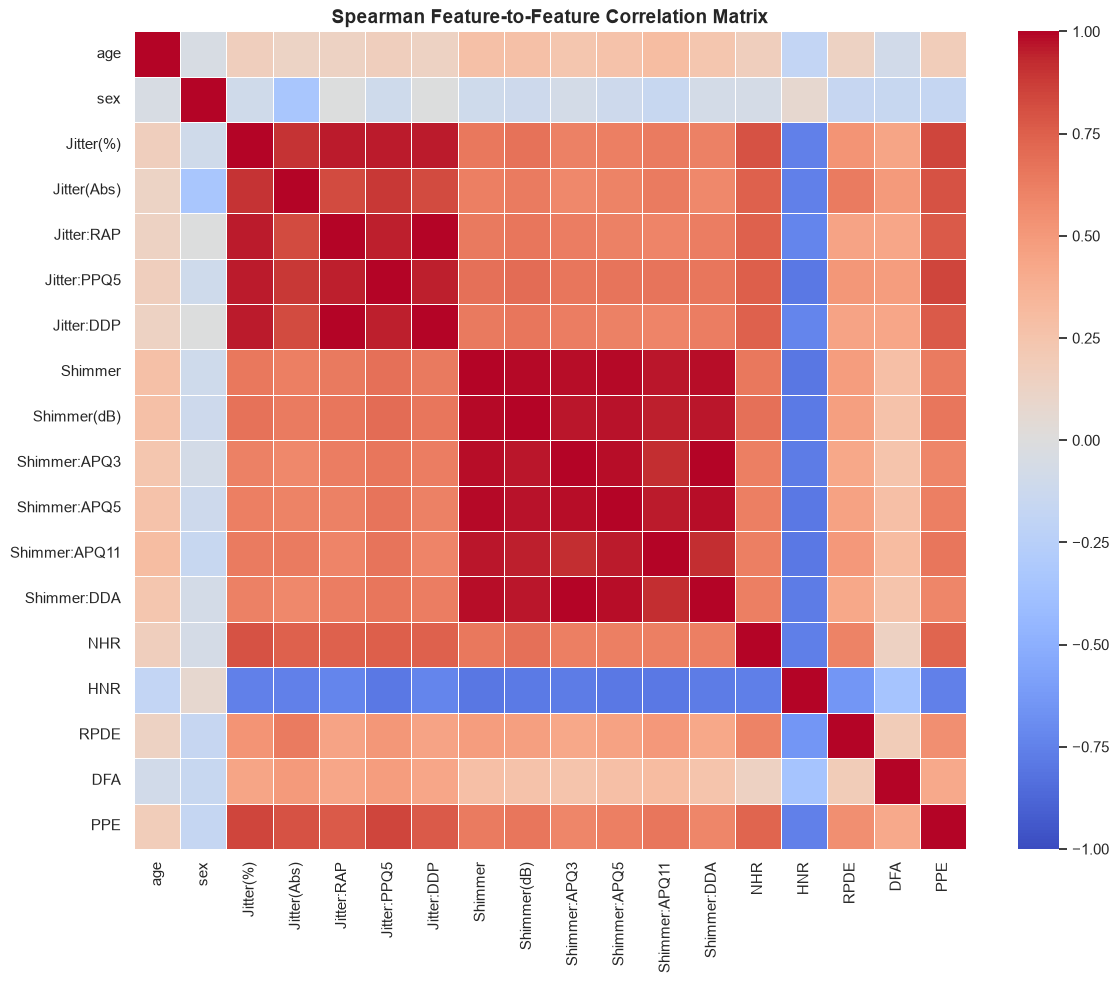

In [13]:
# Compute Spearman correlation matrix for the acoustic features
acoustic_cols = [col for col in pdt.columns if col not in ['subject#', 'test_time', 'motor_UPDRS', 'total_UPDRS']]
corr_matrix = pdt[acoustic_cols].corr(method='spearman') if hasattr(pdt[acoustic_cols], 'corr') else pdt[acoustic_cols].corr(method='spearman')

# Plot the correlation heatmap to expose multicollinearity (e.g., Jitter/Shimmer > 0.95)
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    annot=False, 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5
)
plt.title('Spearman Feature-to-Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

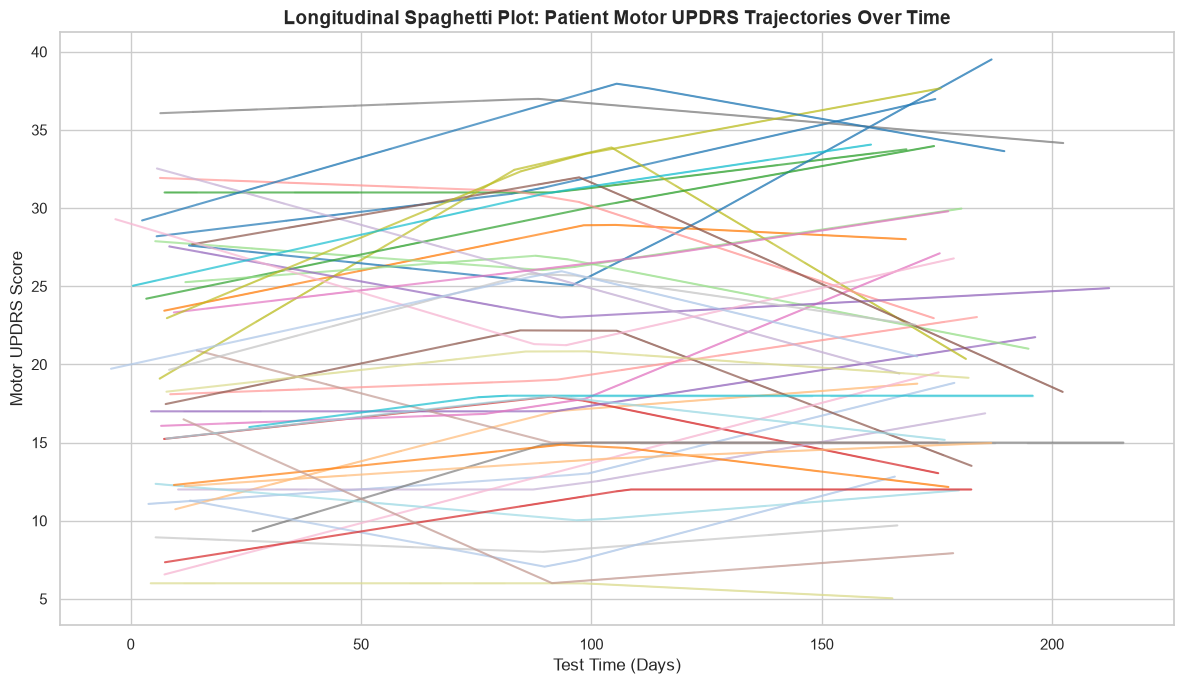

In [14]:
# Create a longitudinal spaghetti plot of motor UPDRS trajectories over time per subject
plt.figure(figsize=(12, 7))
sns.lineplot(
    data=pdt, 
    x='test_time', 
    y='motor_UPDRS', 
    hue='subject#', 
    palette='tab20', 
    linewidth=1.5, 
    alpha=0.7,
    legend=False
)
plt.title('Longitudinal Spaghetti Plot: Patient Motor UPDRS Trajectories Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Test Time (Days)', fontsize=12)
plt.ylabel('Motor UPDRS Score', fontsize=12)
plt.tight_layout()
plt.show()

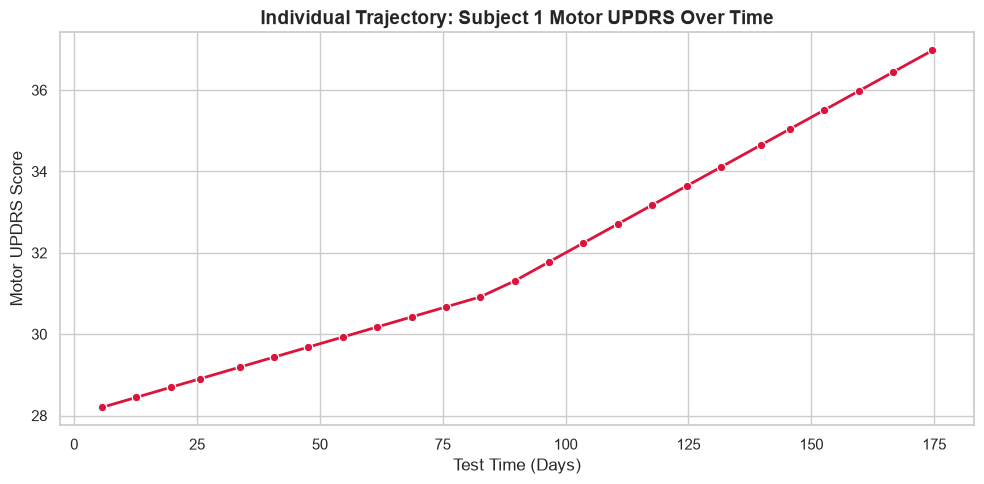

In [15]:
# Filter the dataframe for only Subject 1
subject_1_data = pdt[pdt['subject#'] == 1]

# Plot their individual trajectory over time
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=subject_1_data, 
    x='test_time', 
    y='motor_UPDRS', 
    marker='o', 
    color='crimson', 
    linewidth=2
)
plt.title('Individual Trajectory: Subject 1 Motor UPDRS Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Test Time (Days)', fontsize=12)
plt.ylabel('Motor UPDRS Score', fontsize=12)
plt.tight_layout()
plt.show()

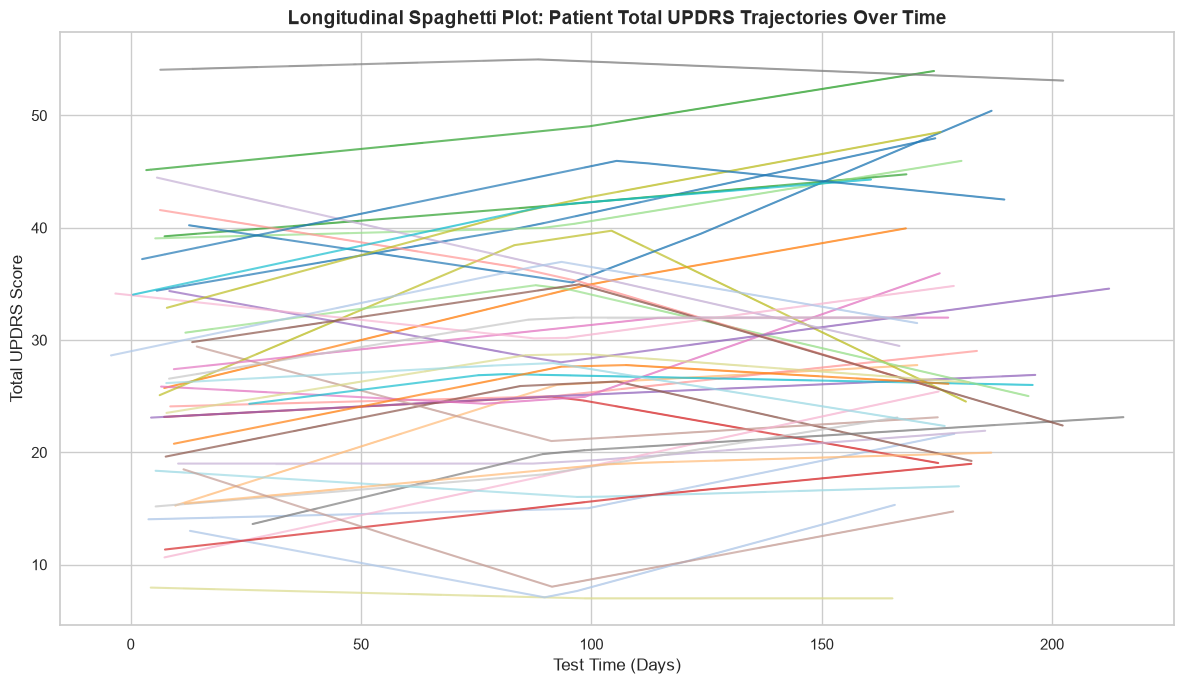

In [16]:
# Create a longitudinal spaghetti plot of total UPDRS trajectories over time per subject
plt.figure(figsize=(12, 7))
sns.lineplot(
    data=pdt, 
    x='test_time', 
    y='total_UPDRS', 
    hue='subject#', 
    palette='tab20', 
    linewidth=1.5, 
    alpha=0.7,
    legend=False
)
plt.title('Longitudinal Spaghetti Plot: Patient Total UPDRS Trajectories Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Test Time (Days)', fontsize=12)
plt.ylabel('Total UPDRS Score', fontsize=12)
plt.tight_layout()
plt.show()

## FEATURE ENGINEERING 

In [33]:
target_cols = ['motor_UPDRS', 'total_UPDRS']

# Compute baseline deltas for both columns simultaneously
pdt[[f'{col}_delta' for col in target_cols]] = (
    pdt[target_cols] - pdt.groupby('subject#')[target_cols].transform('first')
)

In [34]:
pdt.head()

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE,total_UPDRS_delta,motor_UPDRS_delta
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.160060,0.000,0.0
1,1,72,0,5.6431,28.199,34.398,0.00348,0.000015,0.00124,0.00133,...,0.00463,0.00949,0.01234,0.009238,27.927,0.37340,0.52499,0.170660,0.000,0.0
2,1,72,0,5.6438,28.199,34.398,0.00413,0.000021,0.00173,0.00165,...,0.00651,0.01103,0.01665,0.030790,26.641,0.50911,0.53637,0.251830,0.000,0.0
3,1,72,0,5.6451,28.199,34.398,0.00217,0.000011,0.00086,0.00099,...,0.00354,0.00781,0.00812,0.004547,30.749,0.41216,0.54572,0.094704,0.000,0.0
4,1,72,0,5.6458,28.199,34.399,0.00294,0.000015,0.00121,0.00125,...,0.00495,0.00888,0.01377,0.014919,27.530,0.40986,0.53572,0.166350,0.001,0.0


In [37]:
# List your core acoustic features
voice_features = [
    'Jitter(%)', 'Shimmer', 
    'NHR','HNR', 'RPDE', 'DFA', 'PPE'
]

# Compute velocity (delta) for every voice feature simultaneously
for feature in voice_features:
    pdt[f'{feature}_velocity'] = pdt.groupby('subject#')[feature].diff().fillna(0)

In [41]:
pdt.head()

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,RPDE_velocity,DFA_velocity,PPE_velocity,Jitter(%)_roll_mean,Shimmer_roll_mean,NHR_roll_mean,HNR_roll_mean,RPDE_roll_mean,DFA_roll_mean,PPE_roll_mean
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.00000,0.00000,0.000000,0.006620,0.025650,0.014290,21.640000,0.418880,0.548420,0.160060
1,1,72,0,5.6431,28.199,34.398,0.00348,0.000015,0.00124,0.00133,...,-0.04548,-0.02343,0.010600,0.005050,0.018785,0.011764,24.783500,0.396140,0.536705,0.165360
2,1,72,0,5.6438,28.199,34.398,0.00413,0.000021,0.00173,0.00165,...,0.13571,0.01138,0.081170,0.004743,0.016797,0.018106,25.402667,0.433797,0.536593,0.194183
3,1,72,0,5.6451,28.199,34.398,0.00217,0.000011,0.00086,0.00099,...,-0.09695,0.00935,-0.157126,0.003260,0.010907,0.014858,28.439000,0.431557,0.535693,0.172398
4,1,72,0,5.6458,28.199,34.399,0.00294,0.000015,0.00121,0.00125,...,-0.00230,-0.01000,0.071646,0.003080,0.010460,0.016752,28.306667,0.443710,0.539270,0.170961


In [40]:
#For rolling averages to make the data points smooth
rolling_window = 3

for feature in voice_features:
    pdt[f'{feature}_roll_mean'] = (
        pdt.groupby('subject#')[feature]
        .rolling(window=rolling_window, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )

In [ ]:
features_to_drop = ['subject#', 'test_time', 'motor_UPDRS', 'total_UPDRS', 'motor_UPDRS_delta', 'total_UPDRS_delta']
X = pdt.drop(columns=features_to_drop)
y = pdt['motor_UPDRS_delta']
groups = pdt['subject#']

gkf = GroupKFold(n_splits=5)

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

In [ ]:
   # Initialize scaler fresh for this fold
scaler = StandardScaler()
    
    # 2. Fit ONLY on training data, transform validation independently
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)